## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import (VotingRegressor,
    ExtraTreesRegressor,RandomForestRegressor,
    GradientBoostingRegressor)
from xgboost import XGBRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.linear_model import RidgeCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
    KFold,RandomizedSearchCV,cross_val_score)
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,r2_score)

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [ ]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [ ]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


## 1. Análisis Exploratorio de Datos

Se analiza la estructura del dataset, distribución de la variable objetivo y relaciones entre variables.

In [ ]:
print("INFORMACIÓN DEL CONJUNTO DE DATOS")
#Observamos la cantidad de variables y registros que contiene datatraining y datatesting
print("Dimensiones del conjunto de entrenamiento:", dataTraining.shape)
print("Dimensiones del conjunto de prueba:", dataTesting.shape)

print("\nTipos de datos de las variables:")
display(dataTraining.dtypes.to_frame(name="Tipo de dato"))

INFORMACIÓN DEL CONJUNTO DE DATOS
Dimensiones del conjunto de entrenamiento: (79800, 21)
Dimensiones del conjunto de prueba: (34200, 19)

Tipos de datos de las variables:


,Tipo de dato
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


In [ ]:
print("Revisión de valores faltantes:")
faltantes = dataTraining.isnull().sum()

if faltantes.sum() > 0:
    print(faltantes[faltantes > 0])
else:
    print(0)

print("Cantidad de filas duplicadas en entrenamiento:")
print(dataTraining.duplicated().sum())

Revisión de valores faltantes:
0
Cantidad de filas duplicadas en entrenamiento:
0


In [ ]:
# Análisis de las estadisticas descripcivas
dataTraining.describe().round(3)

,Unnamed: 0,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity
count,79800.00,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000,79800.000
mean,39899.50,227902.193,0.567,0.642,5.307,-8.264,0.638,0.085,0.315,0.157,0.213,0.474,122.077,3.903,33.265
std,23036.42,105059.884,0.173,0.251,3.562,5.036,0.481,0.106,0.333,0.311,0.190,0.259,29.942,0.434,22.331
min,0.00,13386.000,0.000,0.000,0.000,-49.307,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,19949.75,174436.000,0.456,0.472,2.000,-10.006,0.000,0.036,0.017,0.000,0.098,0.261,99.081,4.000,17.000
50%,39899.50,212813.000,0.581,0.685,5.000,-7.012,1.000,0.049,0.169,0.000,0.132,0.464,122.009,4.000,35.000
75%,59849.25,261426.000,0.695,0.854,8.000,-5.000,1.000,0.084,0.598,0.050,0.273,0.684,140.054,4.000,50.000
max,79799.00,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,222.605,5.000,100.000


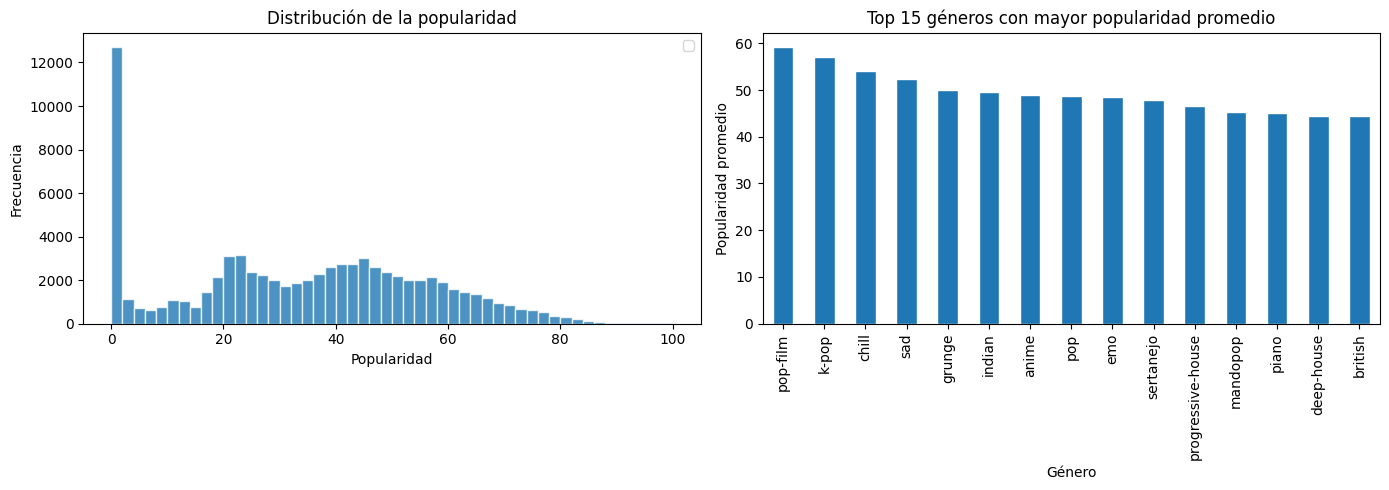

In [ ]:
popularidad = dataTraining["popularity"]

plt.figure(figsize=(14, 5))

# Histograma de popularidad
plt.subplot(1, 2, 1)
plt.hist(popularidad, bins=50, edgecolor="white", alpha=0.8)
plt.title("Distribución de la popularidad")
plt.xlabel("Popularidad")
plt.ylabel("Frecuencia")
plt.legend()

# Top 15 géneros de generos popularidad
top_generos = (dataTraining.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15))
plt.subplot(1, 2, 2)
top_generos.plot(kind="bar", edgecolor="white")
plt.title("Top 15 géneros con mayor popularidad promedio")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
print("\nEstadísticas de la variable de popularidad:")
display(popularidad.describe().round(2).to_frame(name="Valor"))


Estadísticas de la variable de popularidad:


,Valor
count,79800.00
mean,33.27
std,22.33
min,0.00
25%,17.00
50%,35.00
75%,50.00
max,100.00


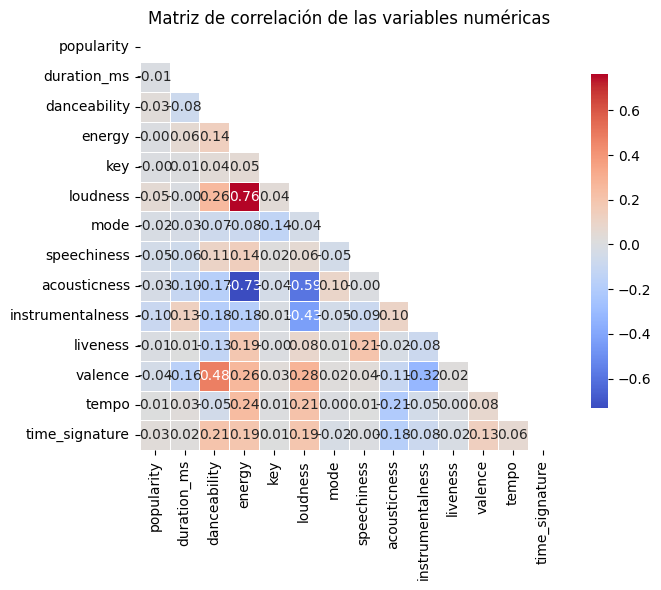


Correlación de las variables con popularity:


,Correlación absoluta
instrumentalness,0.0958
loudness,0.0519
speechiness,0.0451
valence,0.0413
danceability,0.0348
time_signature,0.0331
acousticness,0.0279
mode,0.0153
tempo,0.0136
duration_ms,0.0086


In [ ]:
# Variables numéricas para analizar la correlación
variables_numericas = ["popularity", "duration_ms", "danceability", "energy", "key","loudness", "mode",
                       "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

# Matriz de correlación
correlacion = dataTraining[variables_numericas].corr()
plt.figure(figsize=(8, 6))
mascara = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(correlacion,annot=True,fmt=".2f",cmap="coolwarm",mask=mascara,square=True,linewidths=0.4,cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación de las variables numéricas")
plt.tight_layout()
plt.show()

# Correlación de cada variable con popularity
print("\nCorrelación de las variables con popularity:")
correlacion_popularidad = correlacion["popularity"].drop("popularity")
correlacion_popularidad = correlacion_popularidad.abs().sort_values(ascending=False)

display(correlacion_popularidad.round(4).to_frame(name="Correlación absoluta"))

## 2. Preprocesamiento de Datos



El preprocesamiento se estructuró en tres etapas. Primero, se construyeron variables derivadas a partir de los atributos originales: llaves compuestas de identificación (combinaciones de artista, pista y álbum), una huella de audio basada en la concatenación de características acústicas redondeadas, variables de interacción entre atributos continuos (como el producto entre energía y bailabilidad) y una señal de desviación de cada canción respecto al promedio energético y de bailabilidad de su género.

Segundo, se aplicó target encoding con validación cruzada K-Fold (K=5) sobre seis variables categóricas: identificador de pista, artista principal, álbum, género musical, huella de audio y la combinación artista-álbum. Para evitar filtración del target, la codificación de cada observación se calculó usando únicamente los pliegues restantes, y los valores se suavizaron bayesianamente según la frecuencia de cada categoría. El logaritmo del conteo de apariciones de cada categoría se incluyó como variable adicional.

Finalmente, se extrajeron 100 características textuales mediante TF-IDF sobre la concatenación del nombre de la canción y el artista, ajustado exclusivamente sobre entrenamiento y aplicado de forma transformadora sobre prueba. Las matrices resultantes se concatenaron, se eliminaron columnas de texto e identificadores, y se verificó la alineación entre ambos conjuntos.



In [ ]:
# Configuración Global
SEMILLA = 42
N_FOLDS = 5
TARGET = "popularity"
np.random.seed(SEMILLA)

In [ ]:
#Target encoding Kfold
def kfold_target_encoding(df_train, df_test, col, target, n_folds=5, smoothing=5, devolver_conteos=False):
    global_mean = df_train[target].mean()
    train_enc   = np.full(len(df_train), global_mean, dtype=float)
    train_count = np.zeros(len(df_train), dtype=float)

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEMILLA)
    for tr_idx, val_idx in kf.split(df_train):
        fold_tr = df_train.iloc[tr_idx]
        stats   = fold_tr.groupby(col)[target].agg(['mean', 'count'])
        stats['enc'] = ((stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing))
        valores_val = df_train[col].iloc[val_idx]
        train_enc[val_idx]   = valores_val.map(stats['enc']).fillna(global_mean).values
        train_count[val_idx] = valores_val.map(stats['count']).fillna(0).values

    stats_full = df_train.groupby(col)[target].agg(['mean', 'count'])
    stats_full['enc'] = ((stats_full['count'] * stats_full['mean'] + smoothing * global_mean) / (stats_full['count'] + smoothing))
    test_enc   = df_test[col].map(stats_full['enc']).fillna(global_mean).values
    test_count = df_test[col].map(stats_full['count']).fillna(0).values

    if devolver_conteos:
        return train_enc, test_enc, np.log1p(train_count), np.log1p(test_count)
    return train_enc, test_enc

#Feature engineering
def crear_features_integradas(df_train_ref, df):
    d = df.copy()
    d['explicit'] = d['explicit'].astype(int)

    # Texto normalizado para llaves tipo "misma cancion"
    artista = d['artists'].fillna('').astype(str).str.split(';').str[0].str.strip()
    track_name = d['track_name'].fillna('').astype(str).str.lower().str.strip()
    album_name = d['album_name'].fillna('').astype(str).str.lower().str.strip()

    d['artista_principal'] = artista
    d['artist_track_key']  = artista.str.lower() + ' | ' + track_name
    d['album_track_key']   = album_name + ' | ' + track_name
    d['artist_album_key']  = artista.str.lower() + ' | ' + album_name
    #Huella aproximada de audio: misma grabacion suele tener mismos floats
    audio_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
                  'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    d['audio_key'] = d[audio_cols].round(4).astype(str).apply('|'.join, axis=1)

    # Audio basico
    d['duracion_min'] = d['duration_ms'] / 60_000
    d['loud_norm'] = (d['loudness'] + 60) / 60
    d['energia_baile'] = d['energy'] * d['danceability']
    d['loud_energia'] = d['loud_norm'] * d['energy']
    d['acustica_inv_ener'] = d['acousticness'] * (1 - d['energy'])

    # Diferencia vs promedio del género (Señal de "rareza" o "tendencia")
    genre_stats = df_train_ref.groupby('track_genre')[['energy', 'danceability']].mean()
    d['energy_vs_genero'] = d['energy'] - d['track_genre'].map(genre_stats['energy']).fillna(d['energy'])

    return d

In [ ]:
#Inicio Preprocesamiento de datos
print('Paso 1: Feature engineering base...')
train_fe = crear_features_integradas(dataTraining, dataTraining)
test_fe  = crear_features_integradas(dataTraining, dataTesting)

# Target Encoding
print("Paso 2: Generando Target Encodings K-Fold...")
memoria_cols = []
encoding_jobs = [
    ('trackid_te', 'track_id', 0.1),
    ('artist_te', 'artista_principal', 1.0),
    ('album_te', 'album_name', 2.0),
    ('genre_te', 'track_genre', 10.0),
    ('audio_key_te', 'audio_key', 0.5),
    ('artist_album_te', 'artist_album_key', 1.0)]

for nueva_col, col_orig, smooth in encoding_jobs:
    tr_enc, te_enc, tr_cnt, te_cnt = kfold_target_encoding(
        dataTraining if col_orig in dataTraining.columns else train_fe,
        dataTesting if col_orig in dataTesting.columns else test_fe,
        col_orig, TARGET, n_folds=N_FOLDS, smoothing=smooth, devolver_conteos=True
    )
    train_fe[nueva_col], test_fe[nueva_col] = tr_enc, te_enc
    train_fe[nueva_col+'_cnt'], test_fe[nueva_col+'_cnt'] = tr_cnt, te_cnt
    memoria_cols.append(nueva_col)

# TF-IDF (100 features)
print("Paso 3: TF-IDF")
tfidf = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,1))
corpus_tr = dataTraining['track_name'].fillna('') + " " + dataTraining['artists'].fillna('')
corpus_te = dataTesting['track_name'].fillna('') + " " + dataTesting['artists'].fillna('')
df_tfidf_tr = pd.DataFrame(tfidf.fit_transform(corpus_tr).toarray(), index=dataTraining.index).add_prefix('txt_')
df_tfidf_te = pd.DataFrame(tfidf.transform(corpus_te).toarray(), index=dataTesting.index).add_prefix('txt_')

# Limpieza final de matrices
COLS_DROP = ['Unnamed: 0', 'track_id', 'artists', 'artista_principal', 'album_name',
             'track_name', 'track_genre', 'artist_track_key', 'album_track_key',
             'artist_album_key', 'audio_key', TARGET]

X = pd.concat([train_fe, df_tfidf_tr], axis=1).drop(columns=[c for c in COLS_DROP if c in train_fe.columns])
X_test_final = pd.concat([test_fe, df_tfidf_te], axis=1).drop(columns=[c for c in COLS_DROP if c in test_fe.columns])
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)
y = dataTraining[TARGET].values

print(f'\nFeatures totales: {X.shape[1]} | Filas: {X.shape[0]}')
print(f'NaNs en X: {X.isnull().sum().sum()} | NaNs en X_test: {X_test_final.isnull().sum().sum()}')
print(f'Columnas alineadas: {list(X.columns) == list(X_test_final.columns)}')

Paso 1: Feature engineering base...
Paso 2: Generando Target Encodings K-Fold...
Paso 3: TF-IDF

Features totales: 132 | Filas: 79800
NaNs en X: 0 | NaNs en X_test: 0
Columnas alineadas: True


# 3. MODELAMIENTO


Para el modelado se implementó una arquitectura de stacking de dos niveles. En el nivel base (nivel 0) se entrenaron tres modelos con perfiles complementarios: un XGBoost de árboles profundos, un LightGBM orientado a capturar patrones de alta cardinalidad, y un ExtraTrees que aporta estabilidad por su naturaleza aleatoria en la selección de cortes. Cada modelo se entrenó mediante validación cruzada K-Fold (K=5), guardando las predicciones out-of-fold (OOF) sobre entrenamiento y promediando las predicciones de cada pliegue sobre el conjunto de prueba, lo que garantiza que ningún modelo vea durante su entrenamiento las observaciones sobre las que predice.

Las predicciones OOF de los tres modelos base se concatenaron con las variables de target encoding generadas en el preprocesamiento para construir la matriz de entrada del meta-modelo (nivel 1). Como meta-modelo se utilizó una regresión Ridge con selección automática del parámetro de regularización mediante RidgeCV, evaluando valores entre 0.01 y 50 con validación cruzada interna. Las predicciones finales se acotaron al rango [0, 100] y el desempeño del ensamble se evaluó mediante RMSE sobre las predicciones OOF.

In [ ]:
# DEFINICIÓN DE MODELOS DE NIVEL 0 (DIVERSIDAD ESTRATÉGICA)
modelos_base = [
    ('XGB_profundo', XGBRegressor(
        n_estimators=800, max_depth=9, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
        reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', random_state=42
    )),
    ('LGBM_memoria', LGBMRegressor(
        n_estimators=1000, learning_rate=0.02, num_leaves=127,
        feature_fraction=0.8, min_child_samples=40, random_state=43, verbose=-1
    )),
    ('ExtraTrees_estabilidad', ExtraTreesRegressor(
        n_estimators=350, max_features=0.7, min_samples_leaf=1,
        random_state=44, n_jobs=-1
    ))
]

N_MODELOS_BASE = len(modelos_base)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Matrices para guardar predicciones
oof_modelos = np.zeros((len(X), N_MODELOS_BASE))
test_modelos = np.zeros((len(X_test_final), N_MODELOS_BASE))

# ENTRENAMIENTO DE LOS MODELOS BASE
print(f"Entrenando Nivel 0: Ensamble de {N_MODELOS_BASE} modelos...")

for i, (nombre, modelo) in enumerate(modelos_base):
    print(f'\n[{i+1}/{N_MODELOS_BASE}] Entrenando: {nombre}')
    preds_test_folds = []

    for fold_num, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_va = y[tr_idx], y[val_idx]

        modelo.fit(X_tr, y_tr)

        # Guardamos predicción OOF
        oof_modelos[val_idx, i] = modelo.predict(X_va)
        # Guardamos predicción para Test
        preds_test_folds.append(modelo.predict(X_test_final))
        print(f'  Fold {fold_num+1}/5 completado', end='\r')

    test_modelos[:, i] = np.mean(preds_test_folds, axis=0)
    print(f'  RMSE OOF del modelo: {np.sqrt(mean_squared_error(y, np.clip(oof_modelos[:, i], 0, 100))):.4f}')

# PREPARACIÓN DEL STACKING (NIVEL 1)
print("\n--- Iniciando Meta-Modelo (RidgeCV) ---")
oof_memoria = X[memoria_cols].values
test_memoria = X_test_final[memoria_cols].values

# La matriz de entrada para el meta-modelo tiene 3 (modelos) + N (columnas memoria)
oof_final_input = np.column_stack([oof_modelos, oof_memoria])
test_final_input = np.column_stack([test_modelos, test_memoria])

# El Meta-Modelo busca el mejor compromiso de regularización (alpha)
meta_modelo = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 50.0], scoring='neg_mean_squared_error', cv=5)
meta_modelo.fit(oof_final_input, y)

# 4. EVALUACIÓN FINAL OOF
pred_oof_final = np.clip(meta_modelo.predict(oof_final_input), 0, 100)
rmse_stack = np.sqrt(mean_squared_error(y, pred_oof_final))

print('=' * 50)
print('RESULTADOS DEL SUPER-STACKING')
print(f'RMSE OOF FINAL: {rmse_stack:.4f}')
print(f'Mejor Alpha elegido: {meta_modelo.alpha_}')
print('=' * 50)


Entrenando Nivel 0: Ensamble de 3 modelos...

[1/3] Entrenando: XGB_profundo
  RMSE OOF del modelo: 8.0430

[2/3] Entrenando: LGBM_memoria
  RMSE OOF del modelo: 8.0533

[3/3] Entrenando: ExtraTrees_estabilidad
  RMSE OOF del modelo: 7.8228

--- Iniciando Meta-Modelo (RidgeCV) ---
RESULTADOS DEL SUPER-STACKING
RMSE OOF FINAL: 7.7911
Mejor Alpha elegido: 50.0


Los tres modelos base obtuvieron un RMSE OOF similar, con ExtraTrees como el mejor modelo individual (7.82), seguido de XGBoost (8.04) y LightGBM (8.05). El meta-modelo de stacking logró mejorar sobre todos ellos, alcanzando un RMSE OOF final de 7.79, con un parámetro de regularización alto (α=50), lo que sugiere que el meta-modelo aprendió una combinación conservadora y estable de las predicciones base.

In [ ]:
final_preds = np.clip(meta_modelo.predict(test_final_input), 0, 100)
submission = pd.DataFrame({
    'id': dataTesting.index,
    'popularity': final_preds
})

In [ ]:
y_pred = pd.DataFrame({
    'Popularity': final_preds
}, index=dataTesting.index)

print("Primeras predicciones del conjunto de test:")
display(y_pred.head())

Primeras predicciones del conjunto de test:


,Popularity
0,46.550426
1,14.706557
2,0.528002
3,0.440334
4,26.022744


In [ ]:
y_pred.to_csv('submission_stacking_v5.csv', index_label='ID')


In [ ]:
from google.colab import files
files.download('submission_stacking_v5.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>